In [57]:
!wget https://dsserver-prod-resources-1.s3.amazonaws.com/cnn/xray_dataset.tar.gz

--2026-06-18 19:25:11--  https://dsserver-prod-resources-1.s3.amazonaws.com/cnn/xray_dataset.tar.gz
Resolving dsserver-prod-resources-1.s3.amazonaws.com (dsserver-prod-resources-1.s3.amazonaws.com)... 16.15.191.201, 16.15.229.112, 16.15.191.81, ...
Connecting to dsserver-prod-resources-1.s3.amazonaws.com (dsserver-prod-resources-1.s3.amazonaws.com)|16.15.191.201|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1223407715 (1.1G) [application/x-gzip]
Saving to: ‘xray_dataset.tar.gz.1’

xray_dataset.tar.gz 100%[===================>]   1.14G  15.0MB/s    in 77s     

2026-06-18 19:26:30 (15.2 MB/s) - ‘xray_dataset.tar.gz.1’ saved [1223407715/1223407715]



In [58]:
#Importing and extracting xray images
import tarfile

def extract_tar_gz(file_path, extract_path="."):
    with tarfile.open(file_path, "r:gz") as tar:
        tar.extractall(path=extract_path)
    print("Extraction complete!")

extract_tar_gz("xray_dataset.tar.gz")

/tmp/ipykernel_1758/517228498.py:5: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Extraction complete!


In [59]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models, Model, Input, applications, initializers, regularizers
import matplotlib.pyplot as plt


In [60]:
img_size = (256, 256)
batch_size = 128
val_split = 0.2         # 20% validation split

In [61]:
#load train dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "chest_xray/train",
    labels='inferred',
    label_mode='categorical',
    image_size=img_size,
    batch_size=batch_size,
    validation_split=val_split,
    subset="training",
    seed=417
)

#load validation dataset
val_dataset = tf.keras.utils.image_dataset_from_directory(
    "chest_xray/train",
    labels='inferred',
    label_mode='categorical',
    image_size=img_size,
    batch_size=batch_size,
    validation_split=val_split,
    subset="validation",
    seed=417
)

#load test dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "chest_xray/test",
    labels='inferred',
    label_mode='categorical',
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 5232 files belonging to 2 classes.
Using 4186 files for training.
Found 5232 files belonging to 2 classes.
Using 1046 files for validation.
Found 624 files belonging to 2 classes.


In [62]:
#preprocessing data
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_dataset_normalized = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset_normalized = val_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset_normalized = test_dataset.map(lambda x, y: (normalization_layer(x), y))

In [63]:
class_names = train_dataset.class_names
print(class_names)

['NORMAL', 'PNEUMONIA']


In [64]:
train_dataset_elem = train_dataset.take(1)
for images, labels in train_dataset_elem:
    images = images.numpy()
    labels = labels.numpy()

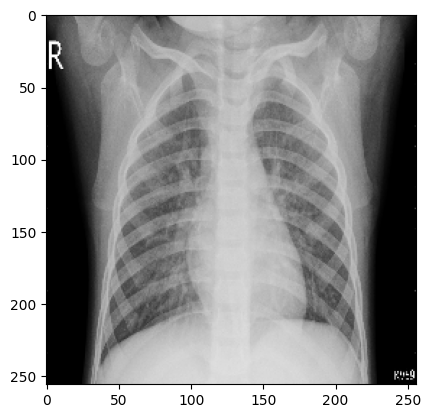

Training Set Image Label: [0. 1.]
Training Set Image Shape: (256, 256, 3)


In [65]:
#Displaying images with labels from train dataset
idx = 0
plt.imshow(images[idx]/255.0)
plt.show()
print(f"Training Set Image Label: {labels[idx]}")
print(f"Training Set Image Shape: {images[idx].shape}")

In [66]:
test_dataset_elem = test_dataset.take(1)
for images, labels in test_dataset_elem:
    images = images.numpy()

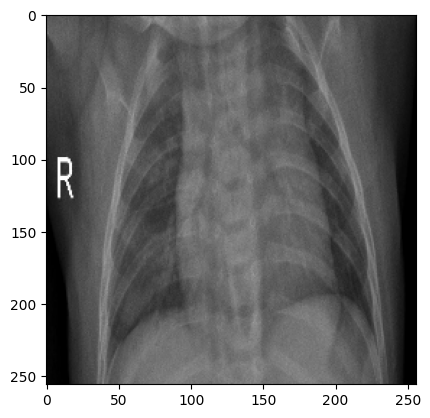

Test Set Image Label: [1. 0.]


In [67]:
#Displaying images with labels from test dataset
idx = 16
plt.imshow(images[idx]/255.0)
plt.show()
print(f"Test Set Image Label: {labels[idx]}")

#CNN Model

In [113]:
#to reduce any overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

In [114]:
cnn_model = models.Sequential([

    layers.Input(shape=(256, 256, 3)),

    # Data augmentation
    data_augmentation,

    # Conv Block 1
    layers.Conv2D(32, (3,3), activation='relu',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D(),

    # Conv Block 2
    layers.Conv2D(64, (3,3), activation='relu',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D(),

    # Conv Block 3
    layers.Conv2D(128, (3,3), activation='relu',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.MaxPooling2D(),

    # Convert features
    layers.GlobalAveragePooling2D(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output layer (2 classes)
    layers.Dense(2, activation='softmax')
])

In [115]:
cnn_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,018 (429.76 KB)

 Trainable params: 110,018 (429.76 KB)

 Non-trainable params: 0 (0.00 B)

In [116]:
#compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

cnn_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#stopping training when a monitored metric has stopped improving
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

#training model block
history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.6295 - loss: 2.7027 - val_accuracy: 0.7629 - val_loss: 0.6476
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7105 - loss: 0.6995 - val_accuracy: 0.7667 - val_loss: 0.6399
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.7289 - loss: 0.6402 - val_accuracy: 0.7945 - val_loss: 0.5409
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 36s 944ms/step - accuracy: 0.7640 - loss: 0.5696 - val_accuracy: 0.8384 - val_loss: 0.5104
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 33s 990ms/step - accuracy: 0.8060 - loss: 0.4929 - val_accuracy: 0.8881 - val_loss: 0.4103
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 32s 970ms/step - accuracy: 0.8306 - loss: 0.4473 - val_accuracy: 0.8786 - val_loss: 0.3586
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 944ms/step - accuracy: 0.8426 - loss: 0.4241 - val_accuracy: 0.8547 - val_loss: 0.3783
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 32s 954ms/step - accuracy: 0.8521 - loss: 0.4127 - val_accuracy: 0.8

In [117]:
#Evaluate model on test dataset
test_loss, test_acc = cnn_model.evaluate(test_dataset)
print("Test Accuracy:", test_acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 681ms/step - accuracy: 0.7740 - loss: 0.5562
Test Accuracy: 0.7740384340286255


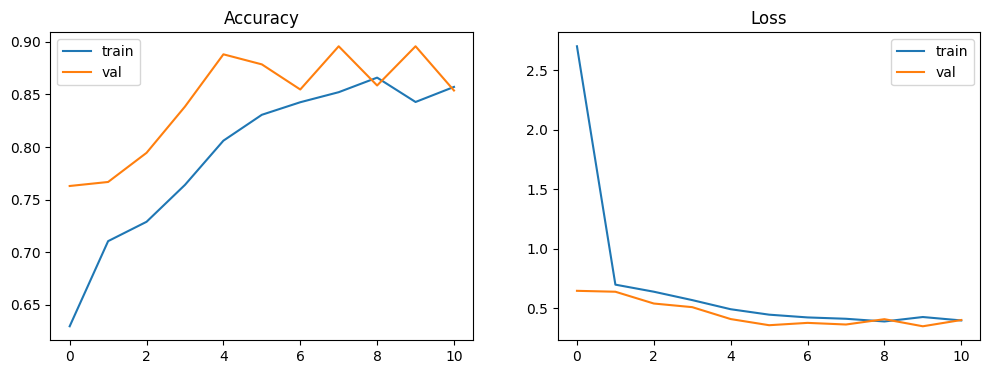

In [118]:
#Plotting figure
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

#ResNet 50


In [96]:
#Load pretrained ResNet base model
base_model = tf.keras.applications.ResNet50V2(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3)
)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [99]:
base_model.trainable = False #freeze base model layers

#Input and preprocessing layers
inputs = tf.keras.Input(shape=(256, 256, 3))

x = tf.keras.applications.resnet50.preprocess_input(inputs)

x = base_model(x, training=False) #connect base model

#pooling and classification head
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(2, activation='softmax')(x)

#final model
resnet_model = tf.keras.Model(inputs, outputs)

In [101]:
resnet_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 256, 256)  │          0 │ input_layer_12[0… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None, 256, 256)  │          0 │ input_layer_12[0… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_8          │ (None, 256, 256)  │          0 │ input_layer_12[0… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 256, 256,  │          0 │ get_item_6[0][0], │
│                     │ 3)                │            │ get_item_7[0][0], │
│                     │                   │            │ get_item_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256, 256,  │          0 │ stack_2[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50v2          │ (None, 8, 8,      │ 23,564,800 │ add_2[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50v2[1][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 2)         │        258 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,827,330 (90.89 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [102]:
#compile model
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#stopping training when a monitored metric has stopped improving
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

#training model block
history = resnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.6209 - loss: 140.5786 - val_accuracy: 0.7686 - val_loss: 27.3834
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.6839 - loss: 45.0939 - val_accuracy: 0.8403 - val_loss: 8.6522
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 32s 960ms/step - accuracy: 0.7568 - loss: 9.3780 - val_accuracy: 0.8470 - val_loss: 2.1167
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 42s 986ms/step - accuracy: 0.7683 - loss: 2.9097 - val_accuracy: 0.8308 - val_loss: 1.0532
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7714 - loss: 0.9399 - val_accuracy: 0.8098 - val_loss: 0.6075
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 38s 992ms/step - accuracy: 0.7788 - loss: 0.7426 - val_accuracy: 0.8155 - val_loss: 0.5521


In [103]:
#Evaluate model on test dataset
val_loss, val_acc = resnet_model.evaluate(val_dataset)
print("Validation Accuracy:", val_acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 743ms/step - accuracy: 0.8470 - loss: 2.1167
Validation Accuracy: 0.8470363020896912


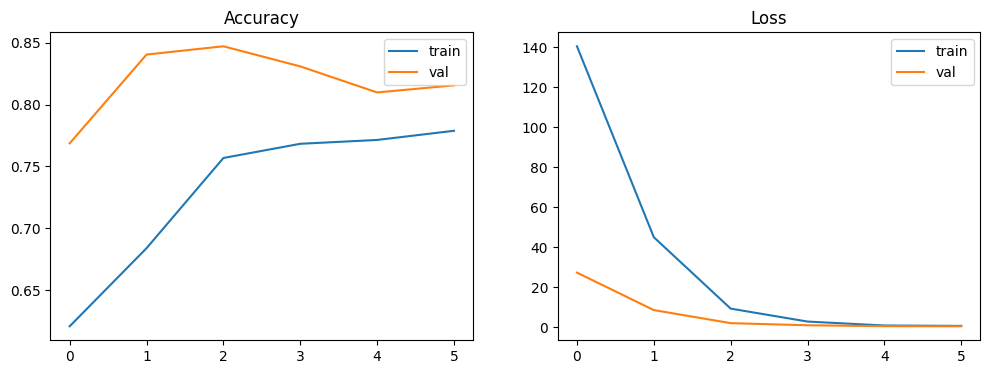

In [104]:
#Plotting figure
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

#ResNet 101

In [105]:
#Load pretrained ResNet base model
base_model = tf.keras.applications.ResNet101V2(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3)
)

171317808/171317808 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [108]:
base_model.trainable = False #freeze base model layers

#Input and preprocessing layers
inputs = tf.keras.Input(shape=(256, 256, 3))

x = tf.keras.applications.resnet_v2.preprocess_input(inputs)

x = base_model(x, training=False)

#pooling and classification head
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(2, activation='softmax')(x)

#final model
resnet_model = tf.keras.Model(inputs, outputs)

In [109]:
resnet_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet101v2 (Functional)        │ (None, 8, 8, 2048)     │    42,626,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,889,090 (163.61 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 42,626,560 (162.61 MB)

In [110]:
#compile model
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#stopping training when a monitored metric has stopped improving
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

#training model block
history = resnet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.7661 - loss: 0.5481 - val_accuracy: 0.8929 - val_loss: 0.2560
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 34s 986ms/step - accuracy: 0.8896 - loss: 0.2693 - val_accuracy: 0.9235 - val_loss: 0.1917
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9185 - loss: 0.2065 - val_accuracy: 0.9359 - val_loss: 0.1672
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9307 - loss: 0.1799 - val_accuracy: 0.9436 - val_loss: 0.1520
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9384 - loss: 0.1622 - val_accuracy: 0.9503 - val_loss: 0.1387
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9455 - loss: 0.1439 - val_accuracy: 0.9512 - val_loss: 0.1306
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9491 - loss: 0.1324 - val_accuracy: 0.9522 - val_loss: 0.1242
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9496 - loss: 0.1253 - val_accuracy: 0.9570 - val_lo

In [111]:
#Evaluate model on test dataset
val_loss, val_acc = resnet_model.evaluate(val_dataset)
print("Validation Accuracy:", val_acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 768ms/step - accuracy: 0.9589 - loss: 0.1093
Validation Accuracy: 0.9588910341262817


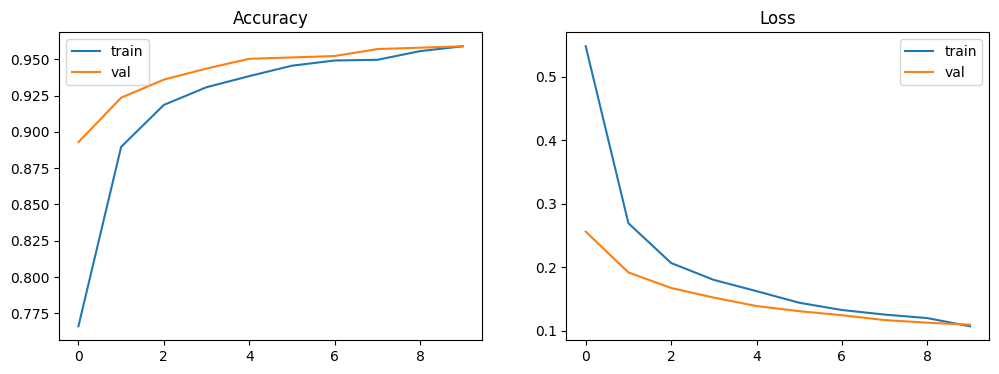

In [112]:
#Plotting figure
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()